## Music League Stats

All of the data is scraped into a pandas dataframe with each row being an entry, with submitter name, song id, votes from all other players, and other stats scraped from the spotify API.

In [41]:
from pathlib import Path
from datetime import datetime, timedelta
from functools import reduce
from operator import add

import numpy as np
import matplotlib.pyplot as plt
from  matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
import matplotlib.dates as mdates


from scraper import translator, create_dataframe
from spotify_data import get_spotify_data, get_playlist, playlists

Dump the files from the downloaded webpage into `/music_league/` in the root of this directory. It has to be the full html and media download, just html doesn't contain the voting information unfortunately.

In [42]:
path = Path("../music_league_3/")

df, names = create_dataframe(path=path, translator=translator) # translator is a dictionary that converts music league names to actual names
df = get_spotify_data(music_league_df=df)

In [43]:
round_names = (
    "Guilty Pleasures",
    "URTEK names",
    "Colours",
    "Duets",
    "Musicals",
    "Sp00ky",
    "Breaking the law",
    "Advert songs",
    "Back to basics",
    "Spotify wrapped tracks"
)

df["round_name"] = df["round"].astype(int).map(lambda i: round_names[i-1])

In [44]:
winning_order = df.groupby(df["submitter"])[names].sum().sum(axis=1)
winning_order = winning_order.sort_values(ascending=False).index

df["round_score"] = df[names].sum(axis=1)

# Round winners

for round_name, (round, scores) in zip(round_names, df.groupby("round")):
    winning_score = scores["round_score"].max()
    a = f"Round {round:<4} | {round_name}"
    print(a + "\n" + '-'*len(a))
    for _, row in scores[scores["round_score"] == winning_score][["submitter", "track_name", "round_score"]].iterrows():
        print(f"{row['submitter']:10} | {row['track_name']:40} | {int(row['round_score'])}")
    print()


Round 1    | Guilty Pleasures
-----------------------------
Mark       | I Lost My Heart to a Starship Trooper    | 14

Round 2    | URTEK names
------------------------
Tim P      | fred                                     | 17

Round 3    | Colours
--------------------
Peter R    | yellow is the color of her eyes          | 20

Round 4    | Duets
------------------
Jenny B    | Easy Lover                               | 19

Round 5    | Musicals
---------------------
Rory       | Sweet Transvestite                       | 18

Round 6    | Sp00ky
-------------------
Fred       | I Put A Spell On You                     | 25

Round 7    | Breaking the law
-----------------------------
Mel        | Psycho Killer                            | 22

Round 8    | Advert songs
-------------------------
Jenny S    | Venus                                    | 17

Round 9    | Back to basics
---------------------------
Rory       | Place To Be                              | 15

Round 10   | Spoti

## Biggest scores per round

In [45]:
df.sort_values("round_score", ascending=False).iloc[:10][["round_name", "submitter", "track_name", "round_score"]]

,round_name,submitter,track_name,round_score
128,Sp00ky,Fred,I Put A Spell On You,25.0
109,Breaking the law,Mel,Psycho Killer,22.0
166,Colours,Peter R,yellow is the color of her eyes,20.0
18,Duets,Jenny B,Easy Lover,19.0
167,Colours,Fred,Redbone,18.0
37,Musicals,Rory,Sweet Transvestite,18.0
74,URTEK names,Tim P,fred,17.0
38,Musicals,Tim P,Angry Inch,17.0
39,Musicals,James,"Pure Imagination - From ""Willy Wonka & The Cho...",17.0
56,Spotify wrapped tracks,Russell,Dancing On My Own,17.0


In [46]:
df.sort_values("round_score", ascending=True).iloc[:10][["round_name", "submitter", "track_name", "round_score"]]

,round_name,submitter,track_name,round_score
184,Colours,Sam,"Love Me Like You Do (From ""50 Shades of Grey"")...",-14.0
73,Spotify wrapped tracks,Peter R,The Place Where He Inserted the Blade,-7.0
36,Duets,Tim P,Harry Potter vs Luke Skywalker,-6.0
127,Breaking the law,Andrej,Ransom,-6.0
72,Spotify wrapped tracks,Jenny S,BIBI Vengeance,-5.0
91,URTEK names,Peter R,"Ghandi, Dalai Lama, Your Lord & Savior J.C. / ...",-5.0
16,Back to basics,Fred,Big Yellow Taxi - Live from Spotify Studios NYC,-5.0
165,Advert songs,Sam,Duncan Hills Coffee Jingle,-5.0
108,Guilty Pleasures,Jamie,Livin' On A Prayer,-4.0
183,Colours,Mark,Lavender,-4.0


## Voting Matrix

The voting matrix shows the net votes of all competitors across all of the rounds. Rows are the points received, columns the points given. The rows and columns are sorted into the final order of the league

In [47]:
# arr has shape (num_rounds, num_competitors, num_competitors)
# Any missing values are filled with 0.0

arr = np.concatenate([
        group.reindex(winning_order, fill_value=0.0).to_numpy()[None, :, :]
        for _, group in df.set_index(df["submitter"]).groupby("round")[winning_order]], axis=0)
voting_matrix = np.sum(arr, axis=0)

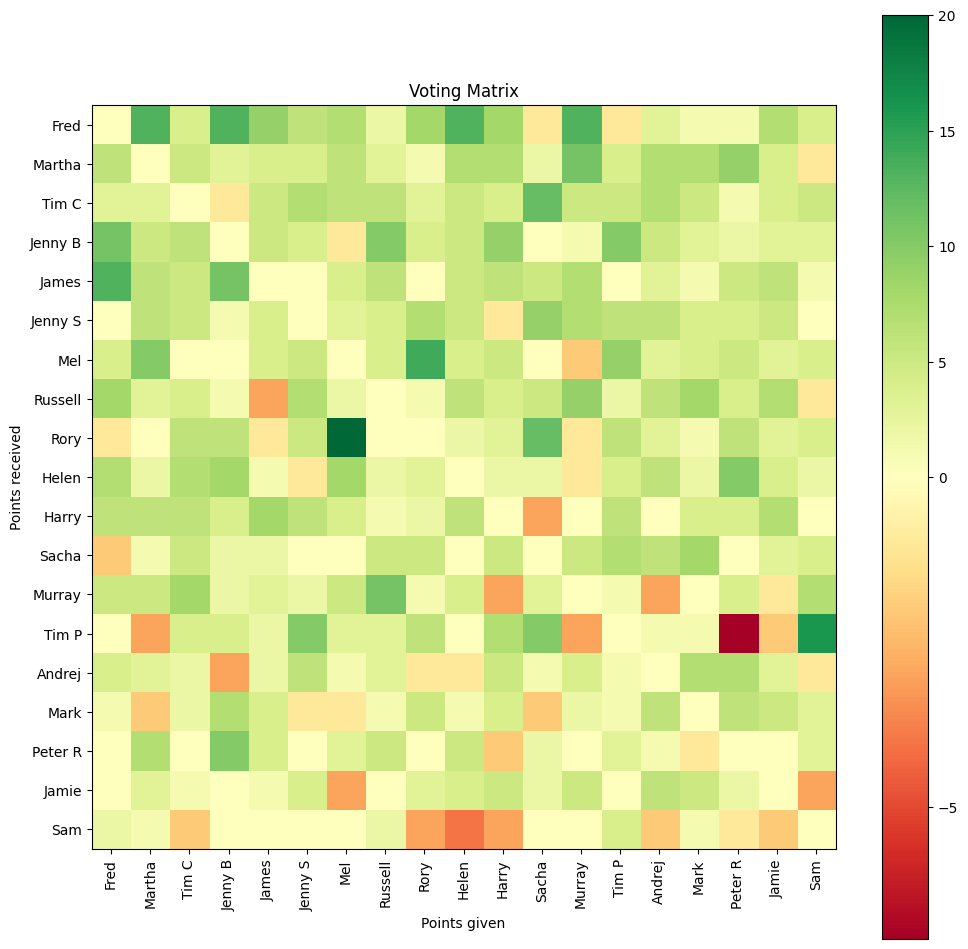

In [48]:
fig, ax = plt.subplots(figsize=(12,12))

cmap=LinearSegmentedColormap.from_list('rg',["r", "w", "g"], N=256)
norm = TwoSlopeNorm(vmin=np.min(voting_matrix),
                        vcenter=0,
                        vmax=np.max(voting_matrix))

plt.imshow(voting_matrix, cmap='RdYlGn', norm=norm, interpolation='nearest')
plt.xticks(np.arange(len(winning_order)), winning_order, rotation='vertical')
plt.yticks(np.arange(len(winning_order)), winning_order)
plt.xlabel("Points given")
plt.ylabel("Points received")
plt.title("Voting Matrix")


cbar = plt.colorbar()

plt.show()

List the top ten biggest stans and haters

In [49]:
most_correlated = np.unravel_index(np.argsort(-voting_matrix.reshape(-1))[:10], voting_matrix.shape)
for row, col in zip(*most_correlated):
    print(f"{winning_order[col]} for {winning_order[row]}: {int(voting_matrix[row, col])}")


Mel for Rory: 20
Sam for Tim P: 16
Rory for Mel: 14
Helen for Fred: 13
Murray for Fred: 13
Fred for James: 13
Jenny B for Fred: 13
Martha for Fred: 13
Sacha for Tim C: 12
Sacha for Rory: 12


In [50]:
biggest_haters = np.unravel_index(np.argsort(voting_matrix.reshape(-1))[:10], voting_matrix.shape)
for row, col in zip(*biggest_haters):
    print(f"{winning_order[col]} for {winning_order[row]}: {int(voting_matrix[row, col])}")


Peter R for Tim P: -7
Helen for Sam: -4
Jenny B for Andrej: -3
Murray for Tim P: -3
Martha for Tim P: -3
Mel for Jamie: -3
James for Russell: -3
Sam for Jamie: -3
Andrej for Murray: -3
Sacha for Harry: -3


## Voting Correlation

See who votes similarly... and who doesn't

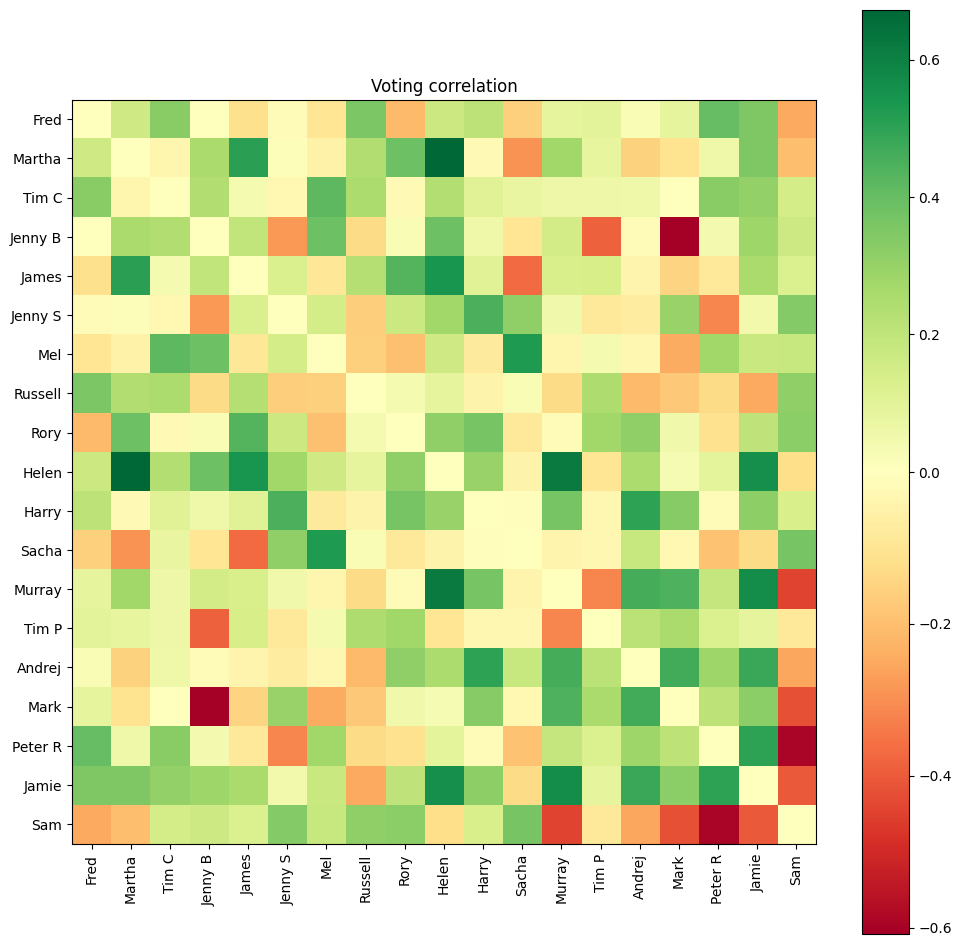

In [51]:
# Sort arr into an array that's lists of each competitors votes per round

voting_correlation = np.corrcoef(np.vstack(voting_matrix).T)
np.fill_diagonal(voting_correlation, 0.0)

fig, ax = plt.subplots(figsize=(12,12))

cmap=LinearSegmentedColormap.from_list('rg',["r", "w", "g"], N=256)
norm = TwoSlopeNorm(vmin=np.min(voting_correlation),
                        vcenter=0,
                        vmax=np.max(voting_correlation))

plt.imshow(voting_correlation, cmap='RdYlGn', norm=norm, interpolation='nearest')
plt.xticks(np.arange(len(winning_order)), winning_order, rotation='vertical')
plt.yticks(np.arange(len(winning_order)), winning_order)
plt.title("Voting correlation")


cbar = plt.colorbar()

plt.show()

In [52]:
most_correlated = np.unravel_index(np.argsort(-voting_correlation.reshape(-1))[:20:2], voting_matrix.shape)
for row, col in zip(*most_correlated):
    print(f"{winning_order[col]} and {winning_order[row]}: {voting_correlation[row, col]:.2f}")

Helen and Martha: 0.67
Helen and Murray: 0.62
Murray and Jamie: 0.57
Helen and Jamie: 0.56
Helen and James: 0.54
Mel and Sacha: 0.53
Martha and James: 0.51
Andrej and Harry: 0.50
Jamie and Peter R: 0.50
Andrej and Jamie: 0.48


In [53]:
most_correlated = np.unravel_index(np.argsort(voting_correlation.reshape(-1))[:20:2], voting_matrix.shape)
for row, col in zip(*most_correlated):
    print(f"{winning_order[col]} and {winning_order[row]}: {voting_correlation[row, col]:.2f}")

Mark and Jenny B: -0.61
Peter R and Sam: -0.59
Murray and Sam: -0.44
Sam and Mark: -0.42
Jamie and Sam: -0.40
Tim P and Jenny B: -0.39
James and Sacha: -0.37
Jenny S and Peter R: -0.32
Tim P and Murray: -0.31
Martha and Sacha: -0.29


## Genre Correlation

See who submits similar genres

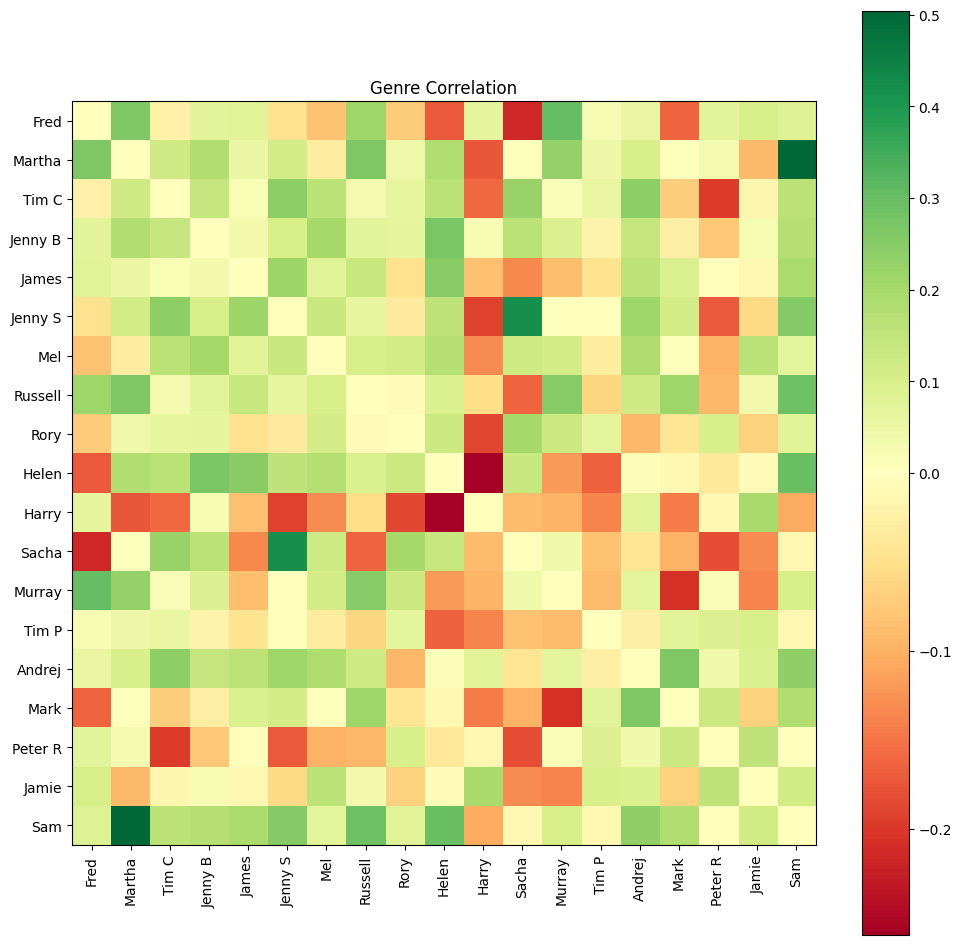

In [54]:
unique_genres = set()

for submitter in winning_order:
    rest = set(reduce(add, df[df.submitter != submitter]["genres"].values))
    unique_genres |= set(reduce(add, df[df.submitter == submitter]["genres"])).difference(rest)

all_genres = list({genre for genres in df.genres for genre in genres}.difference(unique_genres))
from functools import reduce
from operator import add
x = df.groupby("submitter")["genres"].apply(lambda x: reduce(add, x)).reindex(winning_order).map(set)

genre_matrix = np.zeros((len(winning_order), len(all_genres)))

for i, genres in enumerate(x.values):
    for j, genre in enumerate(all_genres):
        if genre in genres:
            genre_matrix[i][j] = 1.0

voting_matrix = np.corrcoef(genre_matrix)
np.fill_diagonal(voting_matrix, 0.0)

fig, ax = plt.subplots(figsize=(12,12))

cmap=LinearSegmentedColormap.from_list('rg',["r", "w", "g"], N=256)
norm = TwoSlopeNorm(vmin=np.min(voting_matrix),
                        vcenter=0,
                        vmax=np.max(voting_matrix))

plt.imshow(voting_matrix, cmap='RdYlGn', norm=norm, interpolation='nearest')
plt.xticks(np.arange(len(winning_order)), winning_order, rotation='vertical')
plt.yticks(np.arange(len(winning_order)), winning_order)
plt.title("Genre Correlation")


cbar = plt.colorbar()

plt.show()

In [55]:
print(f"Most Genre Correlated\n{'-'*21}")
genre_correlated = np.unravel_index(np.argsort(-voting_matrix.reshape(-1))[:20:2], voting_matrix.shape)
for row, col in zip(*genre_correlated):
    print(f"{winning_order[col]} and {winning_order[row]}: {voting_matrix[row, col]:.2f}")

Most Genre Correlated
---------------------
Sam and Martha: 0.50
Jenny S and Sacha: 0.42
Fred and Murray: 0.30
Sam and Helen: 0.29
Sam and Russell: 0.29
Jenny B and Helen: 0.27
Martha and Fred: 0.26
Martha and Russell: 0.26
Andrej and Mark: 0.26
Jenny S and Sam: 0.25


In [56]:
print(f"Least Genre Correlated\n{'-'*21}")
genre_correlated = np.unravel_index(np.argsort(voting_matrix.reshape(-1))[:20:2], voting_matrix.shape)
for row, col in zip(*genre_correlated):
    print(f"{winning_order[col]} and {winning_order[row]}: {voting_matrix[row, col]:.2f}")

Least Genre Correlated
---------------------
Harry and Helen: -0.26
Fred and Sacha: -0.22
Mark and Murray: -0.21
Peter R and Tim C: -0.20
Harry and Jenny S: -0.19
Rory and Harry: -0.19
Sacha and Peter R: -0.18
Martha and Harry: -0.17
Peter R and Jenny S: -0.17
Fred and Helen: -0.17


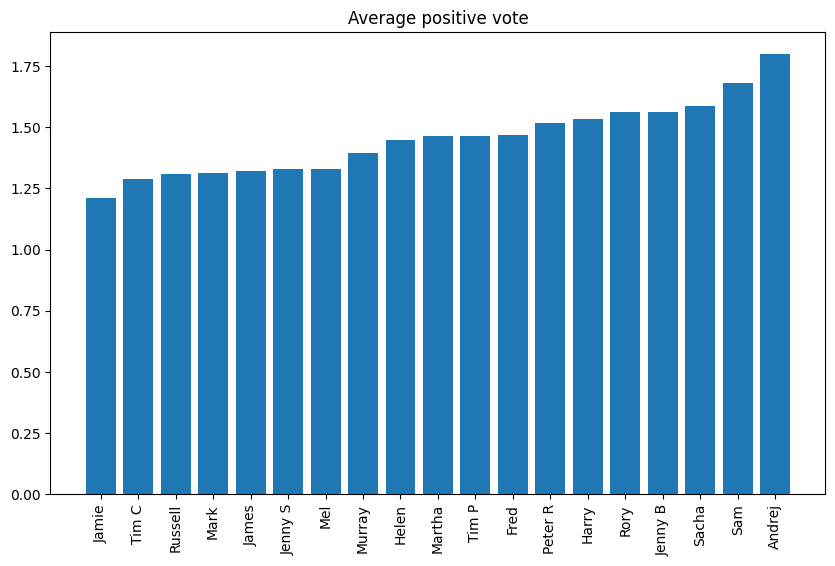

In [57]:
x = arr.reshape(-1, len(winning_order))
x[x <= 0.0] = np.nan
a = np.nanmean(x, axis=0)

fig, ax = plt.subplots(figsize=(10, 6))

ax.set_title("Average positive vote")

ax.bar(np.arange(len(winning_order)), a[np.argsort(a)])
ax.set_xticks(np.arange(len(winning_order)), labels=[winning_order[i] for i in np.argsort(a)], rotation="vertical")

plt.show()

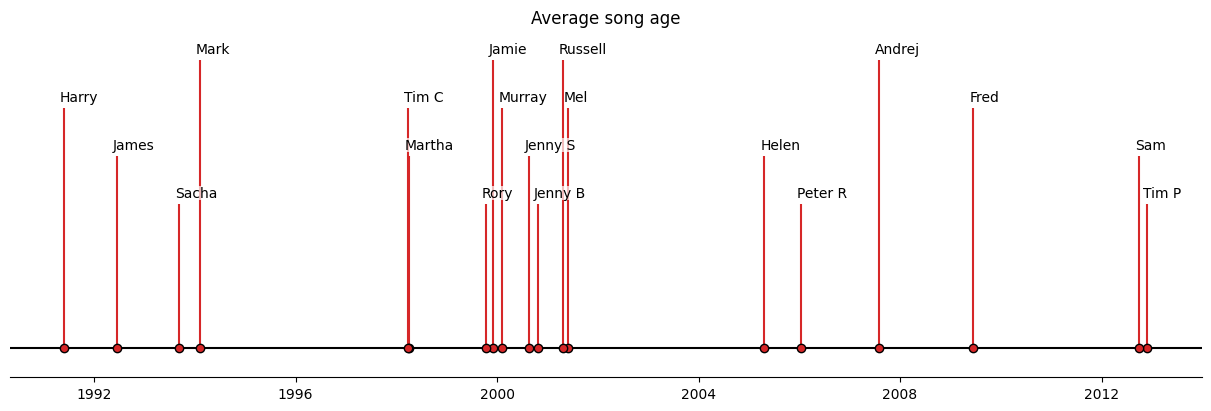

In [162]:
# Average song age

df["song_age_seconds"] = (datetime.now() - df["date"]).dt.total_seconds()
ages = df.groupby("submitter")["song_age_seconds"].mean().sort_values().map(lambda x: datetime.now() - timedelta(seconds=x))

fig, ax = plt.subplots(figsize=(12, 4), layout="constrained")
ax.set(title="Average song age")

levels = [(i % 4) / 3 + 1 for i in range(len(ages))]

# The vertical stems.
ax.vlines(ages, 0, levels,
          color=[("tab:red", 1)
                 for _ in ages])
# The baseline.
ax.axhline(0, c="black")
# The markers on the baseline
ax.plot(ages, np.zeros_like(ages), "ko", mfc="tab:red")

# Annotate the lines.
for date, level, name in zip(ages, levels, ages.index):
    ax.annotate(name, xy=(date, level),
                xytext=(-3, np.sign(level)*3), textcoords="offset points",
                verticalalignment="bottom" if level > 0 else "top",
                bbox=dict(boxstyle='square', pad=0, lw=0, fc=(1, 1, 1, 0.7)))

ax.yaxis.set(major_locator=mdates.YearLocator(),
             major_formatter=mdates.DateFormatter("%Y"))

# Remove the y-axis and some spines.
ax.yaxis.set_visible(False)
ax.spines[["left", "top", "right"]].set_visible(False)

ax.margins(y=0.1)
plt.show()

In [59]:
# Does song age correlate with overall ranking?

np.corrcoef(np.c_[ages.reindex(winning_order).argsort(), np.arange(len(ages))].T)

array([[1.        , 0.21578947],
       [0.21578947, 1.        ]])

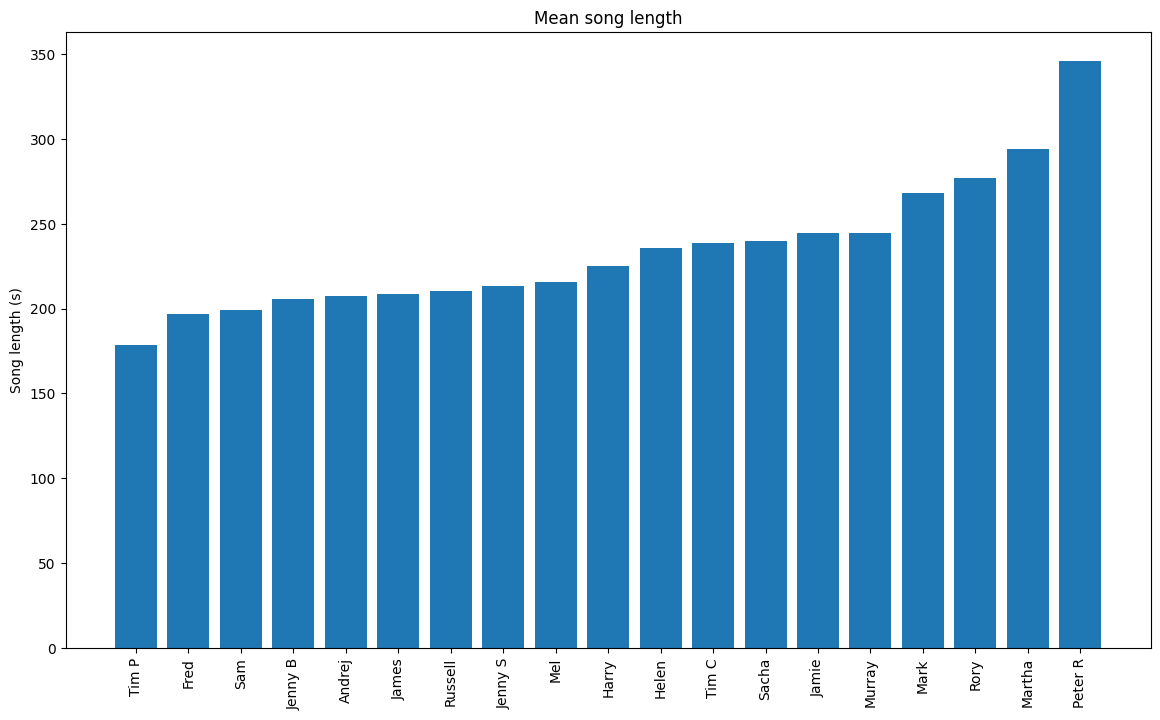

In [60]:
lengths = df.groupby("submitter")["duration"].mean().sort_values()

fig, ax = plt.subplots(figsize=(14, 8))

ax.bar(np.arange(len(lengths)), lengths)
ax.set_xticks(np.arange(len(winning_order)), lengths.index, rotation='vertical')
ax.set_title("Mean song length")
ax.set_ylabel("Song length (s)")
plt.show()

In [61]:
df.sort_values("duration", ascending=False)[["submitter", "track_name", "duration"]].iloc[:10]

,submitter,track_name,duration
154,Peter R,"Polovtsian Dances From ""Prince Igor""",690.306
146,Rory,Black No. 1 (Little Miss Scare -All),675.653
91,Peter R,"Ghandi, Dalai Lama, Your Lord & Savior J.C. / ...",615.028
125,Mark,I Love You... I'll Kill You,532.560
172,Jamie,Purple Rain,521.866
180,Martha,Deacon Blues,455.497
168,Helen,Blue Monday,449.160
130,Tim C,Fear of the Dark - 2015 Remaster,438.120
166,Peter R,yellow is the color of her eyes,435.080
73,Peter R,The Place Where He Inserted the Blade,433.360


In [62]:
df[df["round"]!=8].sort_values("duration")[["submitter", "track_name", "duration"]].iloc[:10]

,submitter,track_name,duration
126,Tim P,Swiper No Swiping!,46.106
81,Andrej,Tim I Wish You Were Born a Girl,106.533
83,Harry,John & James,125.266
104,Fred,My Barn My Rules - Edit,126.530
42,Fred,Guns and Ships,127.578
143,Tim P,"Spooky, Scary Skeletons",127.626
17,Mark,Universal Soldier,133.573
82,Sam,Sam Bond Surf,133.690
103,Helen,Dumbest Girl Alive,137.440
74,Tim P,fred,139.636


In [63]:
# Energy

df.groupby("submitter")["energy"].mean().sort_values(ascending=False)

submitter
Andrej    NaN
Fred      NaN
Harry     NaN
Helen     NaN
James     NaN
Jamie     NaN
Jenny B   NaN
Jenny S   NaN
Mark      NaN
Martha    NaN
Mel       NaN
Murray    NaN
Peter R   NaN
Rory      NaN
Russell   NaN
Sacha     NaN
Sam       NaN
Tim C     NaN
Tim P     NaN
Name: energy, dtype: float64

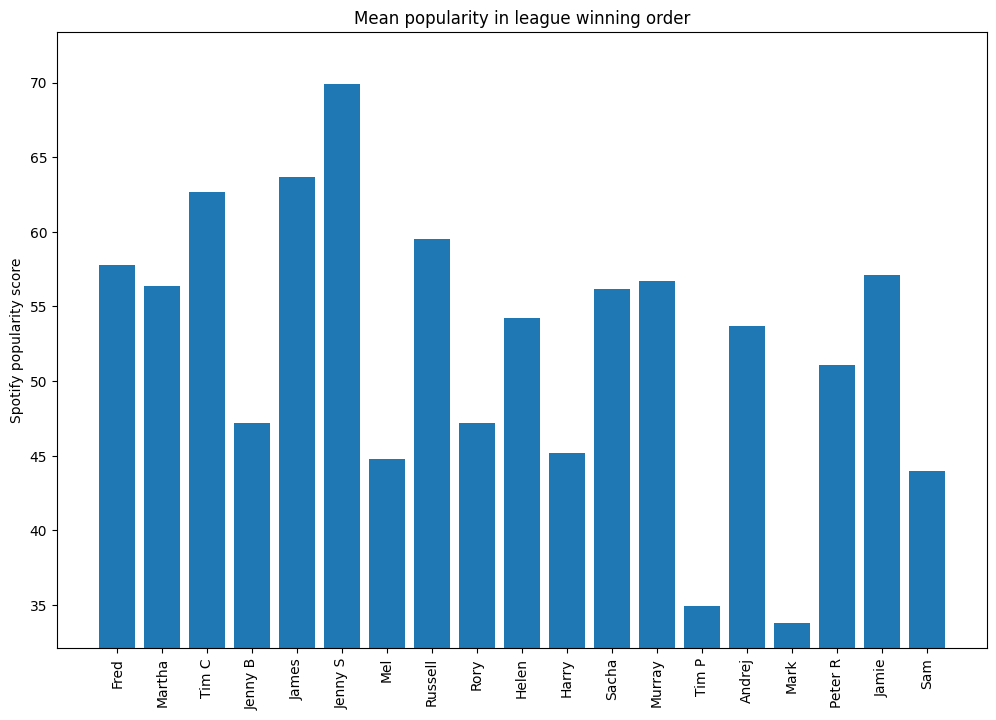

In [64]:
fig, ax = plt.subplots(figsize=(12, 8))

pop = df.groupby("submitter")["popularity"].mean().sort_values(ascending=False)

ax.bar(np.arange(len(pop)), pop.reindex(winning_order))
ax.set_xticks(range(len(pop)), winning_order, rotation="vertical")
ax.set_ylim(min(pop)*0.95, max(pop)*1.05)
ax.set_ylabel("Spotify popularity score")

plt.title("Mean popularity in league winning order")

plt.show()

In [84]:
i, a = list(df.groupby("round"))[0]
playlists = [get_playlist(playlist) for playlist in playlists]
vals = []

for i, a in df.groupby("round"):
    vals.append(a.sort_values("round_score", ascending=False)["song_id"].map(lambda x: playlists[i-1].index(x)))

rankings = np.array([i for df in vals for i in range(len(df))])
playlist_order = np.array([i for df in vals for i in df.values])

# Add noise
playlist_order = playlist_order + np.random.random(*playlist_order.shape) * 0.2

plt.xlabel("round ranking")
plt.ylabel("playlist order")

plt.plot(rankings, playlist_order, "kx")
plt.show()


KeyError: 'tracks'

In [66]:
np.corrcoef(rankings, playlist_order)

array([[ 1.        , -0.06843048],
       [-0.06843048,  1.        ]])

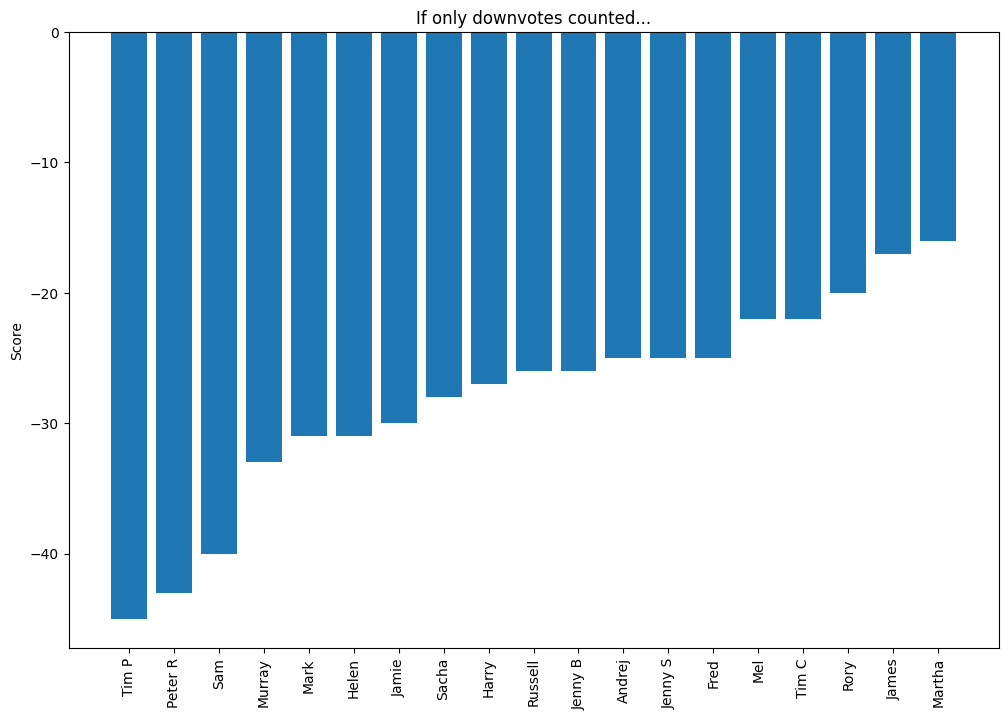

In [67]:
negative_votes = np.where(arr < 0, arr, 0)

negative_scores = np.sum(negative_votes, axis=(0, 2))

order = np.argsort(negative_scores)

fig, ax = plt.subplots(figsize=(12, 8))

ax.bar(np.arange(len(winning_order)), np.sort(negative_scores))
ax.set_xticks(range(len(winning_order)), winning_order[order], rotation="vertical")
ax.set_ylabel("Score")
ax.set_title("If only downvotes counted...")

plt.show()


## Controversy Function

The controversy score $C$ is calculated using the following formula:


$C = \sqrt{\frac{1}{N_{\neq 0}} \sum_{i=1}^{N_{\neq 0}} (v_i - \mu)^2} \times \left( \sum_{i=1}^{n} v_i \text{ where } v_i > 0 \ - \ \alpha \sum_{i=1}^{n} v_i \text{ where } v_i < 0 \right)$


Where:
- $v_i$ are the individual votes.
- $\mu$ is the mean of the non-zero votes.
- $N_{\neq 0}$ is the number of non-zero votes.
- $\alpha$ is the ratio of positive to negative votes ($\frac{10}{3}$ in this league)
- The first part of the equation represents the standard deviation of the non-zero votes.
- The second part represents a modified range that accounts for positive and scaled negative votes.


/home/ferd/music_league_stats/music-league-stats/.venv/lib/python3.10/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/ferd/music_league_stats/music-league-stats/.venv/lib/python3.10/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/ferd/music_league_stats/music-league-stats/.venv/lib/python3.10/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


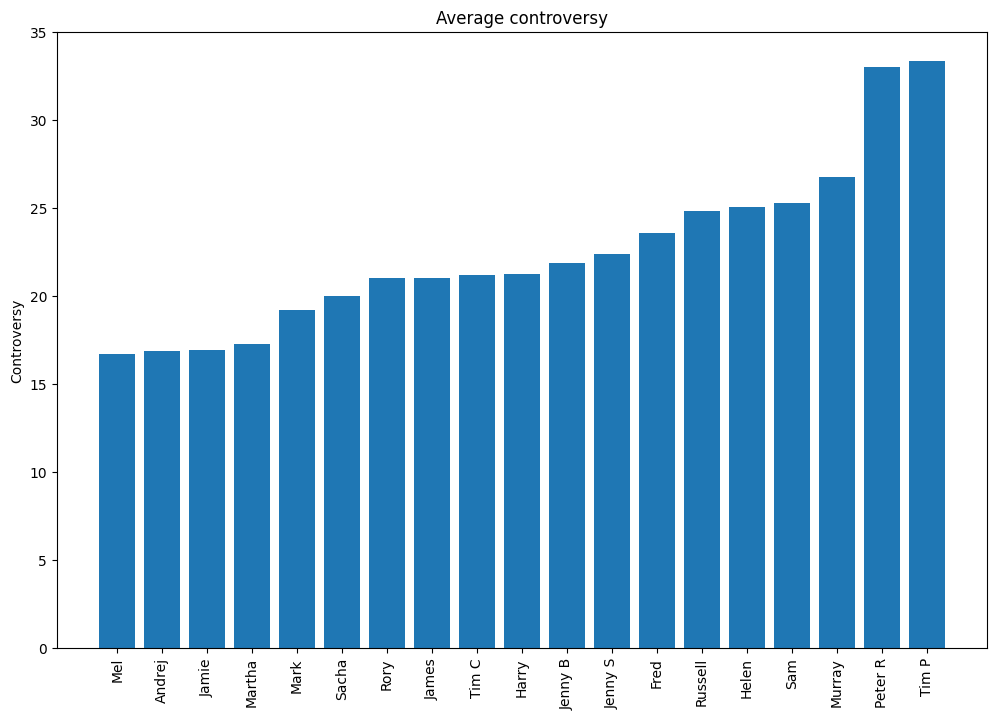

In [68]:
def controversy(vals):
    std = np.std([i for i in vals if i])
    range = sum(i for i in vals if i > 0.0) - (sum(i for i in vals if i < 0.0) * 10/3)
    return std * range
df["controversy"] = df[names].apply(controversy, axis=1)
df.sort_values("controversy", ascending=False)[["submitter", "track_name", "round", "controversy"]].iloc[:10]

fig, ax = plt.subplots(figsize=(12, 8))

vals = df.groupby("submitter")["controversy"].mean().sort_values()

ax.bar(np.arange(len(vals)), vals)
ax.set_xticks(range(len(vals)), vals.index, rotation="vertical")
ax.set_ylabel("Controversy")
ax.set_title("Average controversy")

plt.show()

In [69]:
df.sort_values("controversy", ascending=False)[["controversy", "submitter", "round_name", "track_name"]].iloc[:10]

,controversy,submitter,round_name,track_name
184,118.356805,Sam,Colours,"Love Me Like You Do (From ""50 Shades of Grey"")..."
36,82.860029,Tim P,Duets,Harry Potter vs Luke Skywalker
54,71.527709,Murray,Musicals,Hard Candy Christmas
91,61.079911,Peter R,URTEK names,"Ghandi, Dalai Lama, Your Lord & Savior J.C. / ..."
123,57.250158,Helen,Breaking the law,Kill V. Maim
67,54.372877,Sacha,Spotify wrapped tracks,Never Gonna Give You Up
182,53.200201,Tim P,Colours,It's Corn
48,48.612858,Helen,Musicals,SOS - From 'Mamma Mia!' Original Motion Pictur...
22,47.901133,Russell,Duets,Forgot About Dre
74,46.996526,Tim P,URTEK names,fred


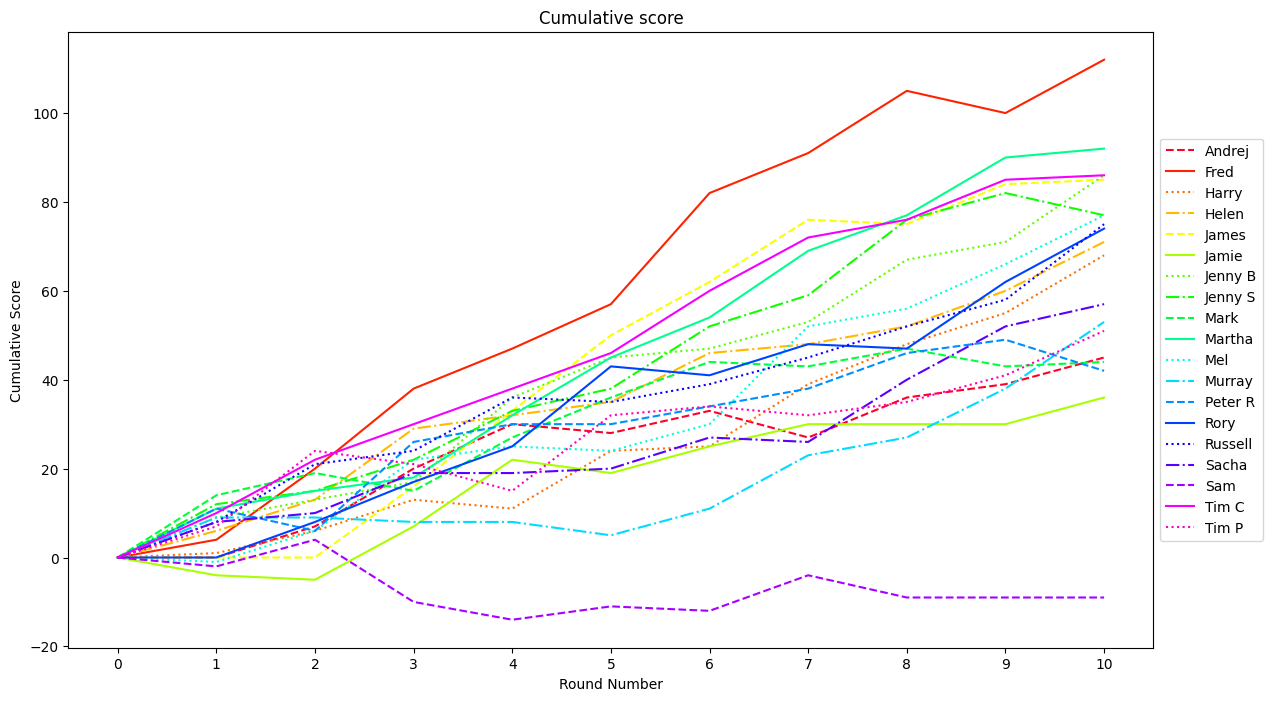

In [170]:
import matplotlib.cm as cm
fig, ax = plt.subplots(figsize=(14, 8))

ls = ("--", "-", ":", "-.")
cmap = cm.gist_rainbow(np.linspace(0, 1, len(df["submitter"].unique())))

scores = {}

for i, (name, rounds) in enumerate(df.groupby("submitter")):
    cumulative_score = [0]    
    for round in sorted(df["round"].unique()):
        if any(mask := rounds["round"]==round):
            cumulative_score.append(rounds[mask]["round_score"].iloc[0] + cumulative_score[-1])
        else:
            cumulative_score.append(cumulative_score[-1])
    scores[name] = cumulative_score
    plt.plot(range(len(cumulative_score)), cumulative_score, label=name, lw=1.5, c=cmap[i], ls=ls[i % len(ls)])

ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

ax.set_title("Cumulative score")
ax.set_xlabel("Round Number")
ax.set_xticks(range(len(cumulative_score)), range(len(cumulative_score)))
ax.set_ylabel("Cumulative Score")
plt.show()

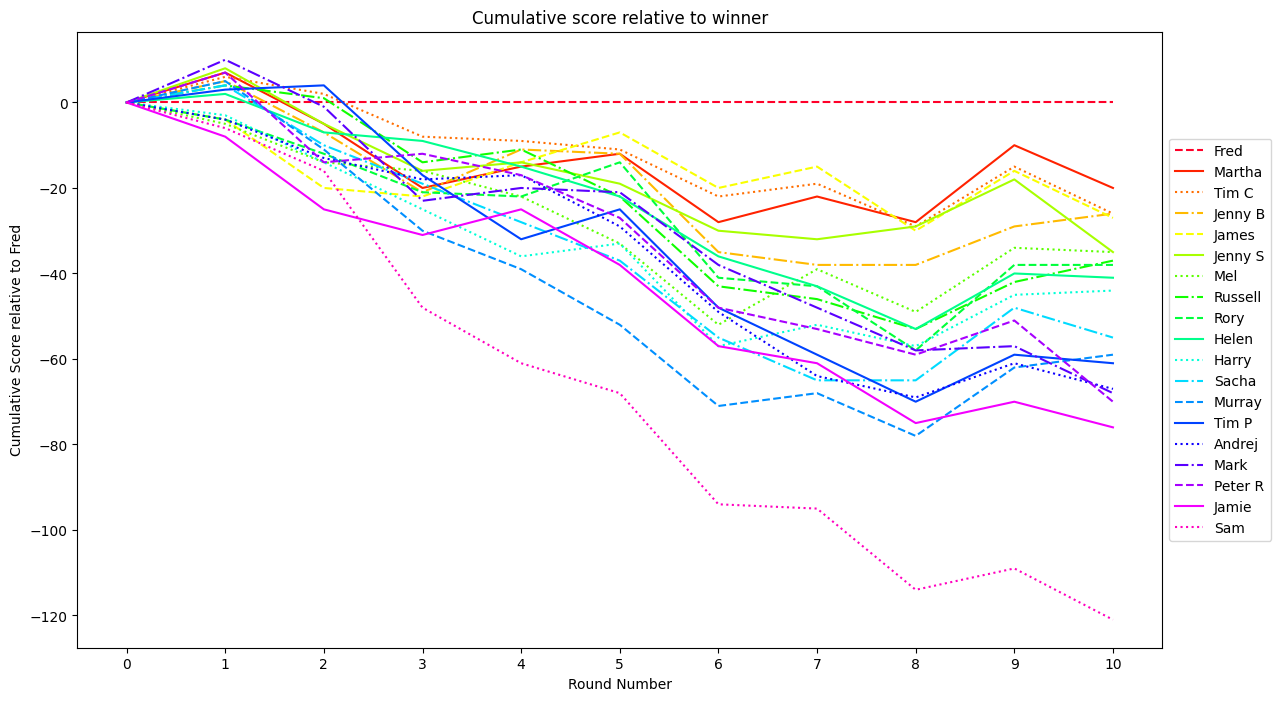

In [171]:
fig, ax = plt.subplots(figsize=(14, 8))

scores = np.array([scores[name] for name in winning_order])

for i, (name, round_scores) in enumerate(zip(winning_order, scores)):
    ax.plot(range(len(round_scores)), round_scores - scores[0], label=name, lw=1.5, c=cmap[i], ls=ls[i % len(ls)])

ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

ax.set_title("Cumulative score relative to winner")
ax.set_xlabel("Round Number")
ax.set_xticks(range(len(cumulative_score)), range(len(cumulative_score)))
ax.set_ylabel(f"Cumulative Score relative to {winning_order[0]}")
plt.show()